# Figure 15.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  09/23/2026          |
| Updated |  09/27/2026          |

Measured strong scaling, i.e., walltime $T_{N_\mathrm{PE}}$ (Footnote 25) vs. the number of processing elements $N_\mathrm{PE}$ (Footnote 24) for $n_\mathrm{p} = 1$ particle runs at $512^2$, and at $1024^2$ for the labeled Athena++ runs.
As in Figure 13, circular markers show runs that implement $n_\mathrm{p} = 1$ particles, while colors differentiate the codes.
The solid gray line shows perfect efficiency $\varepsilon_\parallel = 1$ [equations (23) and (25)] from the serial Athena++ run, which parallel Athena++ runs at $512^2$ exceed by a factor of $1/\varepsilon_\parallel$ [equation (26)].
Dashed lines connect serial runs ($N_\mathrm{PE} = 1$) to parallel runs of the same code, while dotted lines connect two parallel runs and have slopes of $-\varepsilon_\parallel^\mathrm{rel}$ [equation (27)].
The progressive flattening of the $512^2$ Athena++ curve toward larger $N_\mathrm{PE}$ reflects the growing imbalance of particle loads discussed in Section 3.3.1.

eps_rel: Athena 56%, Athena++ 512^2 41%, Athena++ 1024^2 93%
eps_par: Athena++ 16 66%, Athena++ 256 13%, Pencil 16 96%


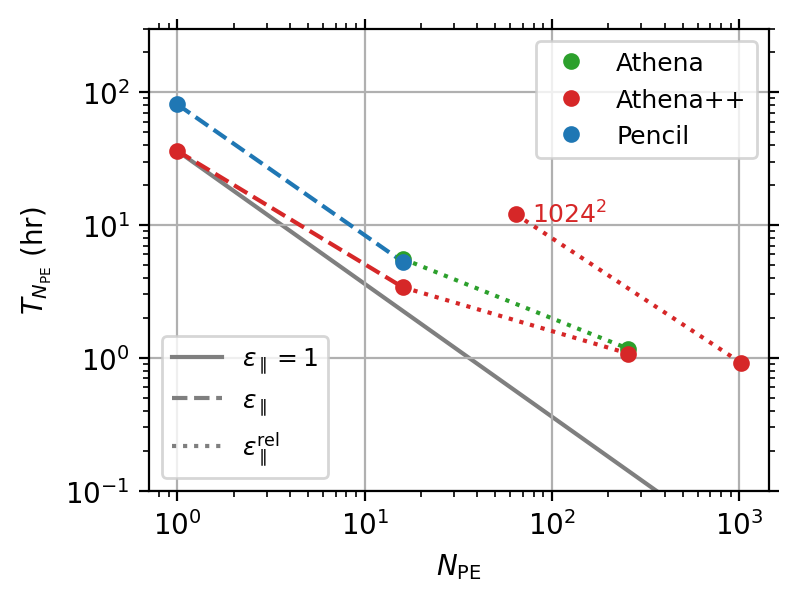

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Core-hours (ch) per run; ref = indices (base, target) for eps_par^rel.
curves = {
    'Athena':   {'npe': np.array([16, 256]),    'ch': np.array([89., 300.]),
                 'ref': (0, 1), 'color': 'tab:green'},
    'Athena++': {'npe': np.array([1, 16, 256]), 'ch': np.array([36.1, 54.4, 276.]),
                 'ref': (1, 2), 'color': 'tab:red'},
    'Pencil':   {'npe': np.array([1, 16]),      'ch': np.array([80.847222, 84.528]),
                 'ref': (0, 1), 'color': 'tab:blue'},
}
ZORDER = {'Athena++': 2, 'Pencil': 3, 'Athena': 4}  # Athena drawn above Athena++
hi_res = {'npe': np.array([64, 1024]), 'ch': np.array([772.3, 940.]),
          'ref': (0, 1), 'color': 'tab:red'}  # Athena++ 1024^2

def pareff(d, n):
    """eps_par = T_1 / (N_PE T_N) = core-h(1) / core-h(N)."""
    return d['ch'][0] / d['ch'][n]

def relpareff(d):
    """eps_par^rel = -ln(T_n / T_0) / ln(N_n / N_0)."""
    i, j = d['ref']
    t = d['ch'] / d['npe']
    return -np.log(t[j] / t[i]) / np.log(d['npe'][j] / d['npe'][i])

def plot_curve(d, z):
    npe, t, c = d['npe'], d['ch'] / d['npe'], d['color']
    for k in range(len(npe) - 1):  # adjacent segments only
        ls = 'dashed' if npe[k] == 1 else 'dotted'
        ax.plot(npe[k:k+2], t[k:k+2], ls=ls, color=c, zorder=z)
    ax.plot(npe, t, ls='none', marker='o', ms=5, color=c, zorder=10)

fig, ax = plt.subplots(figsize=(4, 3), dpi=200)
fs = 9

for code, d in curves.items():
    plot_curve(d, ZORDER[code])
plot_curve(hi_res, ZORDER['Athena++'])
ax.annotate(r'$1024^2$', xy=(hi_res['npe'][0], hi_res['ch'][0] / hi_res['npe'][0]),
            xytext=(6, 0), textcoords='offset points', fontsize=fs,
            color=hi_res['color'], ha='left', va='center')

t1 = curves['Athena++']['ch'][0]  # serial Athena++ walltime (h)
ax.plot([1, 1024], t1 * np.array([1, 1024]) ** -1.0, color='tab:gray', zorder=1)

# Legend 1: codes (upper right). Legend 2: reference lines (lower left).
code_h = [plt.Line2D([], [], ls='none', marker='o', ms=5, color=d['color'], label=code)
          for code, d in curves.items()]
style_h = [plt.Line2D([], [], color='tab:gray', label=r'$\varepsilon_\parallel=1$'),
           plt.Line2D([], [], color='tab:gray', ls='dashed',
                      label=r'$\varepsilon_\parallel$'),
           plt.Line2D([], [], color='tab:gray', ls='dotted',
                      label=r'$\varepsilon_\parallel^\mathrm{rel}$')]
leg_codes = ax.legend(handles=code_h, loc='upper right', fontsize=fs)
ax.add_artist(leg_codes)  # keep legend 1 when legend 2 is added
ax.legend(handles=style_h, loc='lower left', fontsize=fs)

ax.grid()
ax.minorticks_on()
ax.set(xscale='log', xlabel=r'$N_\mathrm{PE}$',
       yscale='log', ylabel=r'$T_{N_\mathrm{PE}}$ (hr)', ylim=(1e-1, 3e2))
ax.tick_params(axis='both', which='both', top=True, right=True)


# Check against text: rel 56/41/93%, eps_par 66/13/96%
print(f"eps_rel: Athena {relpareff(curves['Athena']):.0%}, "
      f"Athena++ 512^2 {relpareff(curves['Athena++']):.0%}, "
      f"Athena++ 1024^2 {relpareff(hi_res):.0%}")
print(f"eps_par: Athena++ 16 {pareff(curves['Athena++'], 1):.0%}, "
      f"Athena++ 256 {pareff(curves['Athena++'], 2):.0%}, "
      f"Pencil 16 {pareff(curves['Pencil'], 1):.0%}")